#### Part A: Feature Map Computation
* Input feature map size: 4 × 4 × 2
* Convolution kernel size: 2 × 2 × 2

#### 1. Regular Convolution (No Padding, Stride = 2)
Formula:
Output size = floor((N − F) / S) + 1

Where:
* N = 4 (input size)
* F = 2 (filter size)
* S = 2 (stride)

Output height = (4 − 2) / 2 + 1 = 2
Output width = (4 − 2) / 2 + 1 = 2

Since one filter is used, output depth = 1

Final output size: 2 × 2 × 1


#### Intermediate Computation

Stride = 2, so filter moves to positions:

* (0,0), (0,2)
* (2,0), (2,2)

Each output value is computed as:

O(i, j) = sum over channels and kernel elements
= Σ (Input × Kernel)

Each involves element-wise multiplication of a 2×2×2 block with the kernel, followed by summation.

Final Feature Map Size: 2 × 2 × 1


#### 2. Regular Convolution (With Zero Padding, Stride = 2)

Assume padding P = 1

New input size = 4 + 2P = 4 + 2 = 6

Output size = (6 − 2) / 2 + 1 = 3

Final output size: 3 × 3 × 1

#### Intermediate Computation

After padding, input becomes 6 × 6 × 2

Filter moves to positions:

* (0,0), (0,2), (0,4)
* (2,0), (2,2), (2,4)
* (4,0), (4,2), (4,4)

Each output value is computed as:

O(i, j) = Σ (Input_padded × Kernel)

At borders, some values in the input are zeros due to padding.

Final Feature Map Size: 3 × 3 × 1


#### 3. Depthwise Convolution (No Padding, Stride = 1)

* Each input channel is convolved with its own filter
* No mixing between channels

So:

* Input channels = 2
* Output channels = 2

#### Output Dimension Calculation

Output size = (4 − 2) / 1 + 1 = 3

Final output size: 3 × 3 × 2


#### Intermediate Computation

For each channel separately:

Channel 1:

O1(i, j) = Σ (Input_channel1 × Kernel_channel1)

Channel 2:

O2(i, j) = Σ (Input_channel2 × Kernel_channel2)

Each uses a 2 × 2 filter on its respective channel.

#### Final Feature Map

Two separate feature maps of size 3 × 3:

Channel 1:

[ O1(0,0)  O1(0,1)  O1(0,2) ]
[ O1(1,0)  O1(1,1)  O1(1,2) ]
[ O1(2,0)  O1(2,1)  O1(2,2) ]

Channel 2:

[ O2(0,0)  O2(0,1)  O2(0,2) ]
[ O2(1,0)  O2(1,1)  O2(1,2) ]
[ O2(2,0)  O2(2,1)  O2(2,2) ]


#### Summary

1. Regular convolution (no padding, stride 2): 2 × 2 × 1
2. Regular convolution (padding = 1, stride 2): 3 × 3 × 1
3. Depthwise convolution (no padding, stride 1): 3 × 3 × 2




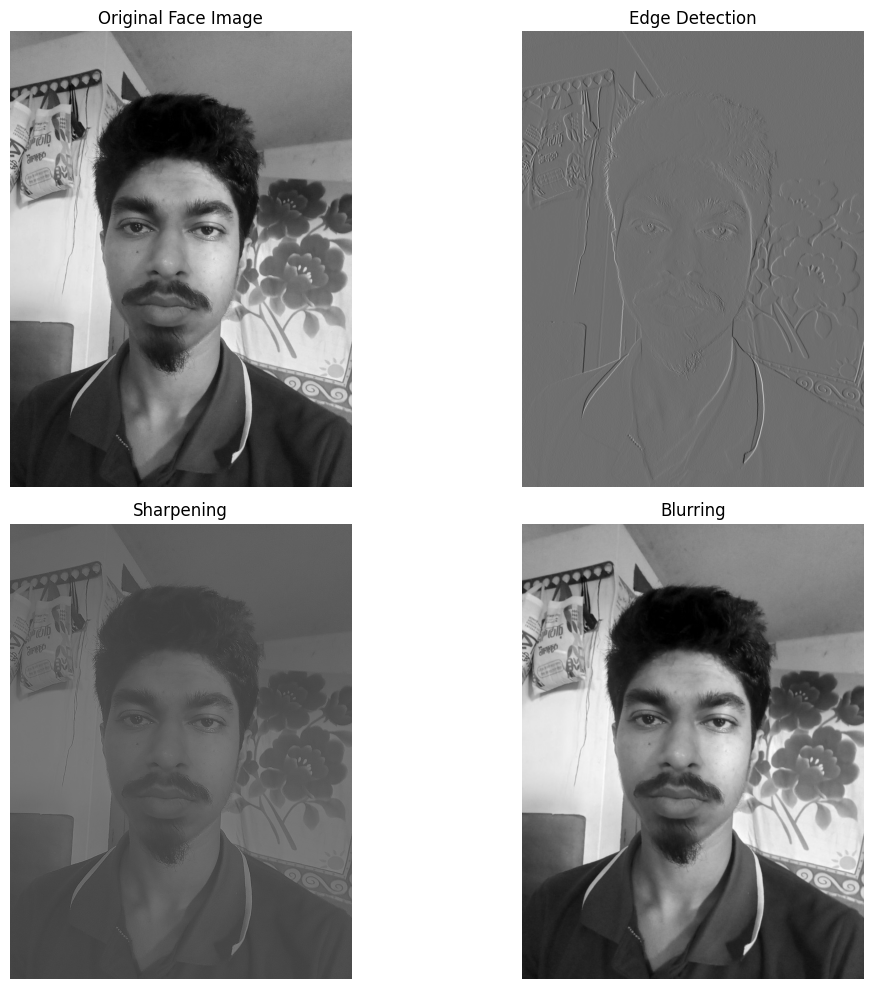

In [3]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from PIL import Image

# Load one of your face images (grayscale for simplicity)
img_path = '/home/saidul/Desktop/4-2/Deep Learning/Assignment1/data/faces/person_0/Saidul_0.jpg' 
img = Image.open(img_path).convert('L')
img_array = np.array(img, dtype=np.float32) / 255.0

# 1. Edge Detection Kernel (Sobel-like)
edge_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# 2. Sharpening Kernel
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# 3. Blurring Kernel (Gaussian approximation)
blur_kernel = np.array([[1, 2, 1],
                        [2, 4, 2],
                        [1, 2, 1]], dtype=np.float32) / 16.0

kernels = {
    'Edge Detection': edge_kernel,
    'Sharpening': sharpen_kernel,
    'Blurring': blur_kernel
}

# Apply and visualize
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_array, cmap='gray')
plt.title('Original Face Image')
plt.axis('off')

for i, (name, kernel) in enumerate(kernels.items(), 2):
    output = signal.convolve2d(img_array, kernel, mode='same', boundary='symm')
    plt.subplot(2, 2, i)
    plt.imshow(output, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Part C: Spatial Separability Analysis

**Spatially Separable Kernels (10 examples)**:
1. Horizontal Edge (Sobel X)
2. Vertical Edge (Sobel Y)
3. Box Blur / Average Filter
4. Gaussian Blur (any size)
5. Prewitt Horizontal
6. Prewitt Vertical
7. Simple Horizontal Line Detector
8. Simple Vertical Line Detector
9. Laplacian of Gaussian (approximated separable)
10. Motion Blur (horizontal or vertical)

**Spatially Non-Separable Kernels (10 examples)**:
1. Diagonal Edge Detector
2. Corner Detector
3. Circular Blob Detector
4. Cross (plus sign) Detector
5. Checkerboard Pattern
6. Arbitrary 3×3 random kernel
7. Sobel combined (magnitude)
8. Laplacian (standard 3×3)
9. Emboss Filter
10. Unsharp Mask (complex)

**Note**: A kernel is spatially separable if it can be written as the outer product of a column vector and a row vector (e.g., Sobel vertical = [-1,0,1]^T × [1,2,1]).


2026-04-26 22:52:32.226894: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 22:52:32.299710: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 22:52:32.396060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-26 22:52:32.484174: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-26 22:52:32.484645: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-26 22:52:32.593705: I tensorflow/core/platform/cpu_feature_guard.cc:

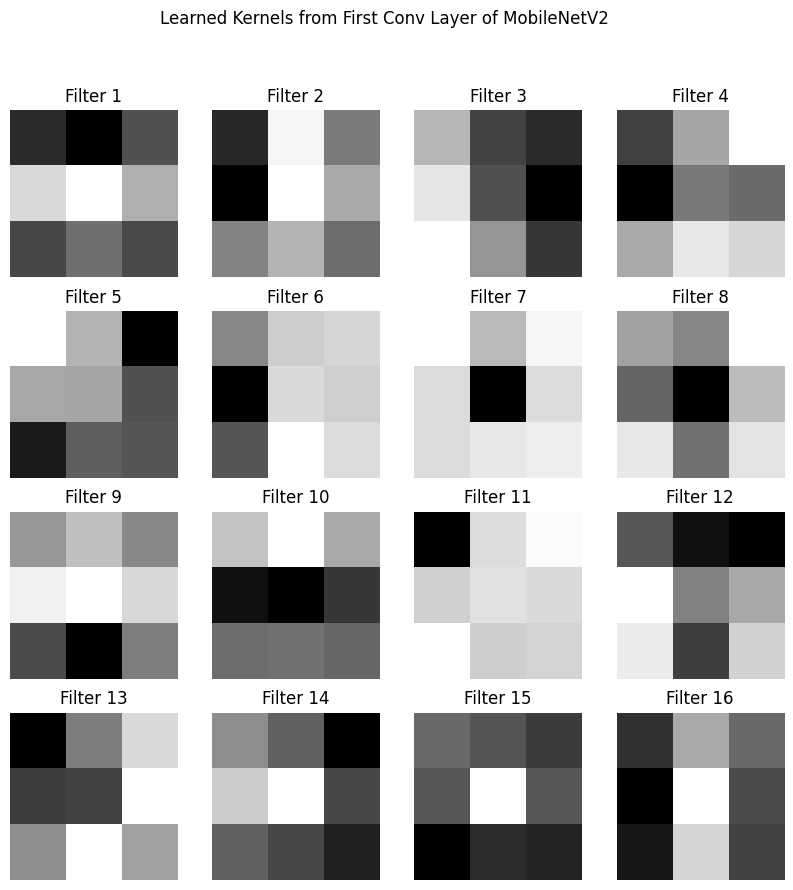

In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# Load pre-trained model
base_model = MobileNetV2(weights='imagenet', include_top=False)

# Get first convolutional layer (Conv1)
layer = base_model.get_layer('Conv1')
filters = layer.get_weights()[0]  # Shape: (3, 3, 3, 32)

# Visualize first 16 filters (first input channel)
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(filters[:, :, 0, i], cmap='gray')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.suptitle('Learned Kernels from First Conv Layer of MobileNetV2')
plt.show()